# Week 1 — ML-Based Legacy Code Risk Prediction

## 1. Project Overview

This notebook builds the Week 1 ML risk predictor for Enterprise Banking HLASM modules.

Objective:

- Predict modernization risk: **Low / Medium / High**
- Use measurable legacy-code features
- Compare baseline and improved models
- Explain model behavior using feature importance
- Save final artifacts for dashboard / prediction use

## 2. Import Libraries

In [158]:
from pathlib import Path
import json
import joblib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import GridSearchCV

## 3. Load Dataset

In [159]:
cwd = Path.cwd()

if cwd.name == 'notebooks':
    PROJECT_ROOT = cwd.parent.parent
elif cwd.name == 'ml_risk_predictor':
    PROJECT_ROOT = cwd.parent
else:
    PROJECT_ROOT = cwd

DATA_PATH = PROJECT_ROOT / 'ml_risk_predictor' / 'data' / 'enterprise_banking_hlasm_risk_dataset_v5.csv'
ARTIFACTS_DIR = PROJECT_ROOT / 'ml_risk_predictor' / 'artifacts'
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

print('Project root:', PROJECT_ROOT)
print('Dataset path:', DATA_PATH)

df = pd.read_csv(DATA_PATH)
print('Dataset loaded successfully')
print('Rows:', df.shape[0])
print('Columns:', df.shape[1])

df.head()

Project root: c:\Users\dhanu\HLASM-to-Java-Translator-with-ML-Based-Behavioral-Validation
Dataset path: c:\Users\dhanu\HLASM-to-Java-Translator-with-ML-Based-Behavioral-Validation\ml_risk_predictor\data\enterprise_banking_hlasm_risk_dataset_v5.csv
Dataset loaded successfully
Rows: 1000
Columns: 17


,application_name,business_process,module_name,module_role,lines_of_code,branch_instruction_count,called_module_count,calling_module_count,file_io_count,database_access_count,macro_call_count,packed_decimal_instruction_count,historical_defect_count,change_count_last_12_months,comment_ratio,unsupported_instruction_count,risk_level
0,Savings Accounts,Withdrawal Processing,BALI92,Interface,262,47,6,10,1,4,10,45,5,10,0.57,1,Low
1,Loans,Interest Calculation,CALCI66,Interface,4420,9,4,6,0,1,4,37,1,6,0.43,2,Medium
2,Reporting,Month End Reporting,GLMR06,ReportWriter,8605,189,21,20,11,5,34,18,18,19,0.09,8,High
3,Customer Management,Profile Maintenance,CUSTI95,Interface,4877,104,11,14,1,9,4,37,3,21,0.16,0,Medium
4,Customer Management,Customer Onboarding,ONBRU89,Utility,3908,171,6,21,18,6,9,72,27,38,0.08,12,High


## 4. Exploratory Data Analysis (EDA)

In [160]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   application_name                  1000 non-null   str    
 1   business_process                  1000 non-null   str    
 2   module_name                       1000 non-null   str    
 3   module_role                       1000 non-null   str    
 4   lines_of_code                     1000 non-null   int64  
 5   branch_instruction_count          1000 non-null   int64  
 6   called_module_count               1000 non-null   int64  
 7   calling_module_count              1000 non-null   int64  
 8   file_io_count                     1000 non-null   int64  
 9   database_access_count             1000 non-null   int64  
 10  macro_call_count                  1000 non-null   int64  
 11  packed_decimal_instruction_count  1000 non-null   int64  
 12  historical_defect_

In [161]:
df.describe(include='all')

,application_name,business_process,module_name,module_role,lines_of_code,branch_instruction_count,called_module_count,calling_module_count,file_io_count,database_access_count,macro_call_count,packed_decimal_instruction_count,historical_defect_count,change_count_last_12_months,comment_ratio,unsupported_instruction_count,risk_level
count,1000,1000,1000,1000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000
unique,10,39,1000,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3
top,Savings Accounts,Interest Posting,BALI92,Calculation,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Medium
freq,111,48,1,143,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,355
mean,NaN,NaN,NaN,NaN,4003.833000,81.026000,7.972000,12.164000,7.375000,5.855000,13.421000,38.338000,11.839000,14.20200,0.250610,4.070000,NaN
std,NaN,NaN,NaN,NaN,2443.527398,55.453317,6.258305,7.573273,4.646931,4.338756,8.684422,23.766417,9.076313,9.87769,0.150299,3.321164,NaN
min,NaN,NaN,NaN,NaN,141.000000,3.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.00000,0.000000,0.000000,NaN
25%,NaN,NaN,NaN,NaN,1822.750000,36.000000,3.000000,6.000000,4.000000,2.000000,7.000000,18.000000,5.000000,6.00000,0.140000,2.000000,NaN
50%,NaN,NaN,NaN,NaN,4017.500000,65.000000,6.000000,11.000000,7.000000,5.000000,11.000000,37.000000,10.000000,12.00000,0.230000,3.000000,NaN
75%,NaN,NaN,NaN,NaN,5817.000000,115.000000,12.000000,18.000000,11.000000,9.000000,19.000000,56.000000,17.000000,21.00000,0.340000,6.000000,NaN


In [162]:
risk_counts = df['risk_level'].value_counts()
risk_counts

risk_level
Medium    355
High      324
Low       321
Name: count, dtype: int64

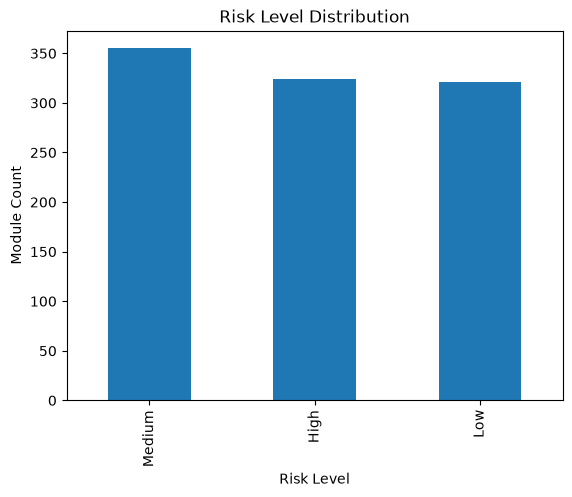

In [163]:
plt.figure()
risk_counts.plot(kind='bar')
plt.title('Risk Level Distribution')
plt.xlabel('Risk Level')
plt.ylabel('Module Count')
plt.show()

In [164]:
df.groupby('application_name')['risk_level'].value_counts().unstack(fill_value=0)

risk_level,High,Low,Medium
application_name,,,
Compliance,34,30,32
Credit Cards,29,32,39
Current Accounts,33,27,35
Customer Management,36,34,35
Fixed Deposits,35,32,29
Loans,31,31,34
Payments,21,32,35
Reporting,37,33,37
Savings Accounts,40,35,36


## 5. Data Cleaning

In [165]:
print('Missing values per column:')
df.isna().sum()

Missing values per column:


application_name                    0
business_process                    0
module_name                         0
module_role                         0
lines_of_code                       0
branch_instruction_count            0
called_module_count                 0
calling_module_count                0
file_io_count                       0
database_access_count               0
macro_call_count                    0
packed_decimal_instruction_count    0
historical_defect_count             0
change_count_last_12_months         0
comment_ratio                       0
unsupported_instruction_count       0
risk_level                          0
dtype: int64

In [166]:
df = df.drop_duplicates(subset=['module_name']).copy()

for col in df.select_dtypes(include=['object']).columns:
    df[col] = df[col].astype(str).str.strip()

print('Rows after duplicate cleanup:', len(df))

Rows after duplicate cleanup: 1000


C:\Users\dhanu\AppData\Local\Temp\ipykernel_30732\1382087969.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include=['object']).columns:


## 6. Feature Engineering

For Week 1, we keep features simple and explainable.

We intentionally use `branch_instruction_count` instead of cyclomatic complexity because branch count is directly measurable from HLASM without needing a full CFG.

### Why is `module_name` excluded?

If we train the model with module_name, the model may simply memorize that:                                  
MAINDRV → High                                                         
AUTHDEC → Medium                                                                                     
FEECALC → Low                                                
instead of learning why a module is high or low risk.

In [167]:
TARGET_COLUMN = 'risk_level'

CATEGORICAL_COLUMNS = ['application_name', 'business_process', 'module_role']

NUMERIC_COLUMNS = [
    'lines_of_code',
    'branch_instruction_count',
    'called_module_count',
    'calling_module_count',
    'file_io_count',
    'database_access_count',
    'macro_call_count',
    'packed_decimal_instruction_count',
    'historical_defect_count',
    'change_count_last_12_months',
    'comment_ratio',
    'unsupported_instruction_count',
]

DROP_COLUMNS = ['module_name']

X = df.drop(columns=[TARGET_COLUMN] + DROP_COLUMNS)
y = df[TARGET_COLUMN]

print('Categorical features:', CATEGORICAL_COLUMNS)
print('Numeric features:', NUMERIC_COLUMNS)

X.head()

Categorical features: ['application_name', 'business_process', 'module_role']
Numeric features: ['lines_of_code', 'branch_instruction_count', 'called_module_count', 'calling_module_count', 'file_io_count', 'database_access_count', 'macro_call_count', 'packed_decimal_instruction_count', 'historical_defect_count', 'change_count_last_12_months', 'comment_ratio', 'unsupported_instruction_count']


,application_name,business_process,module_role,lines_of_code,branch_instruction_count,called_module_count,calling_module_count,file_io_count,database_access_count,macro_call_count,packed_decimal_instruction_count,historical_defect_count,change_count_last_12_months,comment_ratio,unsupported_instruction_count
0,Savings Accounts,Withdrawal Processing,Interface,262,47,6,10,1,4,10,45,5,10,0.57,1
1,Loans,Interest Calculation,Interface,4420,9,4,6,0,1,4,37,1,6,0.43,2
2,Reporting,Month End Reporting,ReportWriter,8605,189,21,20,11,5,34,18,18,19,0.09,8
3,Customer Management,Profile Maintenance,Interface,4877,104,11,14,1,9,4,37,3,21,0.16,0
4,Customer Management,Customer Onboarding,Utility,3908,171,6,21,18,6,9,72,27,38,0.08,12


In [168]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print('Training rows:', X_train.shape[0])
print('Testing rows:', X_test.shape[0])

Training rows: 800
Testing rows: 200


## Preprocessor:
"Our dataset contains both categorical features, such as application name and module role, and numeric software metrics, "
"such as lines of code and branch instruction count. The ColumnTransformer applies one-hot encoding to categorical features while passing numeric features through unchanged, "
"producing a unified numeric feature matrix suitable for machine learning."

In [169]:
preprocessor = ColumnTransformer(
    transformers=[
        ('categorical', OneHotEncoder(handle_unknown='ignore'), CATEGORICAL_COLUMNS),
        ('numeric', 'passthrough', NUMERIC_COLUMNS),
    ]
)

In [170]:
def evaluate_model(model_name, pipeline, X_test, y_test):
    y_pred = pipeline.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    report_text = classification_report(y_test, y_pred)
    report_dict = classification_report(y_test, y_pred, output_dict=True)
    matrix = confusion_matrix(y_test, y_pred, labels=['Low', 'Medium', 'High'])

    print('=' * 70)
    print(model_name)
    print('=' * 70)
    print('Accuracy:', round(accuracy, 4))
    print()
    print(report_text)

    disp = ConfusionMatrixDisplay(confusion_matrix=matrix, display_labels=['Low', 'Medium', 'High'])
    disp.plot()
    plt.title(f'Confusion Matrix - {model_name}')
    plt.show()

    return {
        'model_name': model_name,
        'accuracy': accuracy,
        'classification_report': report_dict,
        'confusion_matrix': matrix.tolist(),
    }

## 7. Baseline Model

Baseline Model - Logistic Regression
Accuracy: 0.625

              precision    recall  f1-score   support

        High       0.61      0.75      0.68        65
         Low       0.71      0.69      0.70        64
      Medium       0.55      0.45      0.50        71

    accuracy                           0.62       200
   macro avg       0.62      0.63      0.62       200
weighted avg       0.62      0.62      0.62       200



c:\Users\dhanu\HLASM-to-Java-Translator-with-ML-Based-Behavioral-Validation\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


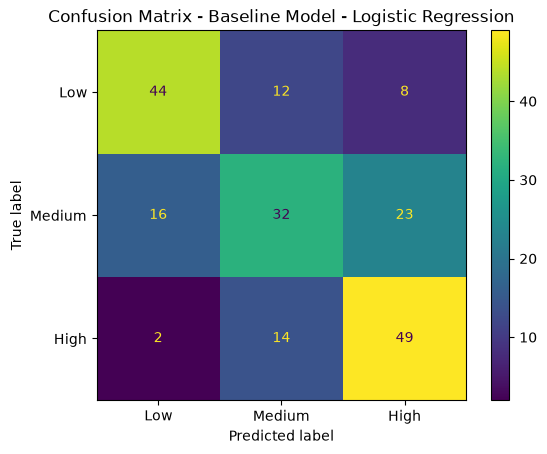

In [171]:
baseline_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', LogisticRegression(max_iter=1000, class_weight='balanced')),
    ]
)   

baseline_model.fit(X_train, y_train)

baseline_results = evaluate_model('Baseline Model - Logistic Regression', baseline_model, X_test, y_test)

## 8. Improved Models

Improved Model - Decision Tree
Accuracy: 0.83

              precision    recall  f1-score   support

        High       0.88      0.86      0.87        65
         Low       0.82      0.94      0.88        64
      Medium       0.79      0.70      0.75        71

    accuracy                           0.83       200
   macro avg       0.83      0.83      0.83       200
weighted avg       0.83      0.83      0.83       200



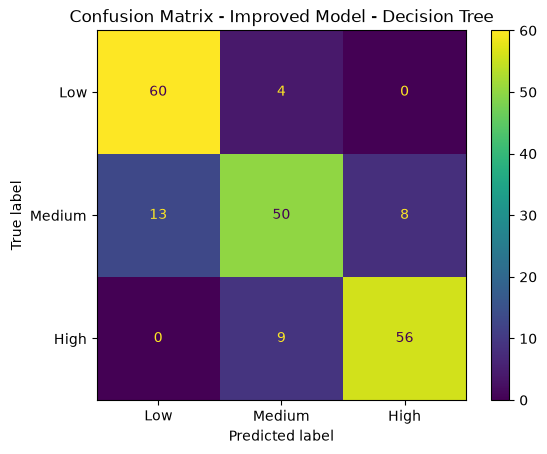

In [172]:
tree_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', DecisionTreeClassifier(random_state=42, class_weight='balanced', max_depth=8)),
    ]
)

tree_model.fit(X_train, y_train)

tree_results = evaluate_model('Improved Model - Decision Tree', tree_model, X_test, y_test)

Random Forest
Accuracy: 0.865

              precision    recall  f1-score   support

        High       0.86      0.94      0.90        65
         Low       0.87      0.94      0.90        64
      Medium       0.87      0.73      0.79        71

    accuracy                           0.86       200
   macro avg       0.87      0.87      0.86       200
weighted avg       0.87      0.86      0.86       200



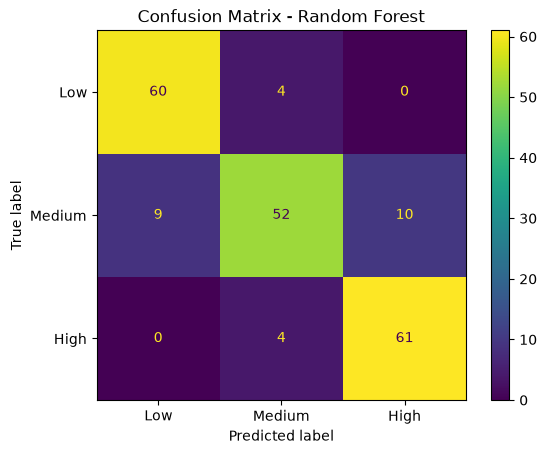

In [173]:
rf_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', RandomForestClassifier(n_estimators=250, random_state=42, class_weight='balanced')),
    ]
)

rf_model.fit(X_train, y_train)

rf_results = evaluate_model('Random Forest', rf_model, X_test, y_test)

In [181]:
from sklearn.preprocessing import LabelEncoder

xgb_label_encoder = LabelEncoder()

y_train_xgb = xgb_label_encoder.fit_transform(y_train)
y_test_xgb = xgb_label_encoder.transform(y_test)

print("Classes:", xgb_label_encoder.classes_)

Classes: ['High' 'Low' 'Medium']


XGBoost
Accuracy: 0.845

              precision    recall  f1-score   support

        High       0.85      0.92      0.88        65
         Low       0.86      0.92      0.89        64
      Medium       0.83      0.70      0.76        71

    accuracy                           0.84       200
   macro avg       0.84      0.85      0.84       200
weighted avg       0.84      0.84      0.84       200



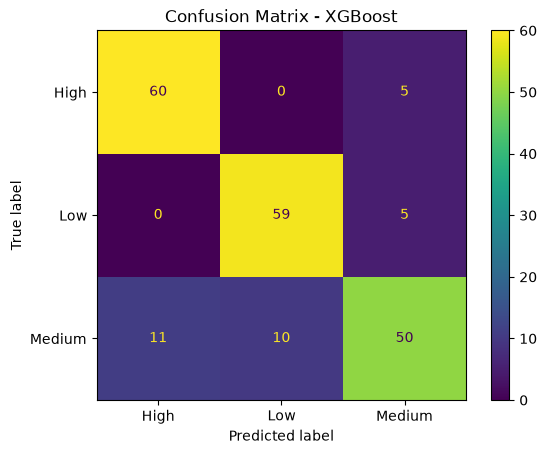

In [183]:
# XGBoost Classifier
from xgboost import XGBClassifier

xgb_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", XGBClassifier(
            n_estimators=200,
            max_depth=6,
            learning_rate=0.1,
            objective="multi:softprob",
            eval_metric="mlogloss",
            random_state=42
        ))
    ]
)

xgb_model.fit(X_train, y_train_xgb)

y_pred_xgb = xgb_model.predict(X_test)

xgb_accuracy = accuracy_score(y_test_xgb, y_pred_xgb)

print("=" * 70)
print("XGBoost")
print("=" * 70)
print("Accuracy:", round(xgb_accuracy, 4))
print()
print(classification_report(
    y_test_xgb,    # actual test labels: 200
    y_pred_xgb,    # predicted test labels: 200
    target_names=xgb_label_encoder.classes_
))

xgb_matrix = confusion_matrix(y_test_xgb, y_pred_xgb)

disp = ConfusionMatrixDisplay(
    confusion_matrix=xgb_matrix,
    display_labels=xgb_label_encoder.classes_
)
disp.plot()
plt.title("Confusion Matrix - XGBoost")
plt.show()

xgb_results = {
    "model_name": "XGBoost",
    "accuracy": xgb_accuracy,
}

In [184]:

# ------------------------------------------------------------
# Grid Search for Hyperparameter Tuning of Random Forest Classifier
# ------------------------------------------------------------


param_grid = {
    "model__n_estimators": [150, 250, 350],
    "model__max_depth": [10, 15, 20, None],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
}

grid_search = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1,
)

print("Running hyperparameter tuning...")
grid_search.fit(X_train, y_train)

print("Best Parameters:")
print(grid_search.best_params_)

print("Best Cross-Validation Accuracy:")
print(round(grid_search.best_score_, 4))



Running hyperparameter tuning...
Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best Parameters:
{'model__max_depth': 10, 'model__min_samples_leaf': 1, 'model__min_samples_split': 5, 'model__n_estimators': 150}
Best Cross-Validation Accuracy:
0.915


Final Tuned Random Forest
Accuracy: 0.865

              precision    recall  f1-score   support

        High       0.86      0.94      0.90        65
         Low       0.87      0.94      0.90        64
      Medium       0.87      0.73      0.79        71

    accuracy                           0.86       200
   macro avg       0.87      0.87      0.86       200
weighted avg       0.87      0.86      0.86       200



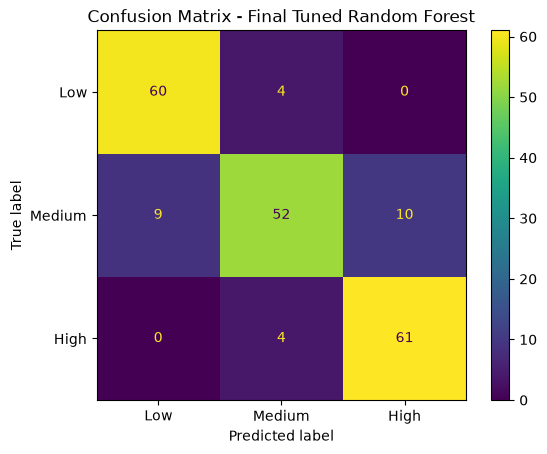

In [185]:
final_tuned_rf_model = grid_search.best_estimator_

final_tuned_rf_results = evaluate_model(
    "Final Tuned Random Forest",
    final_tuned_rf_model,
    X_test,
    y_test
)

## 9. Model Comparison

In [186]:
comparison_df = pd.DataFrame([
    {"model": baseline_results["model_name"], "accuracy": baseline_results["accuracy"]},
    {"model": tree_results["model_name"], "accuracy": tree_results["accuracy"]},
    {"model": rf_results["model_name"], "accuracy": rf_results["accuracy"]},
    {"model": xgb_results["model_name"], "accuracy": xgb_results["accuracy"]},
    {"model": final_tuned_rf_results["model_name"], "accuracy": final_tuned_rf_results["accuracy"]},
])
comparison_df

,model,accuracy
0,Baseline Model - Logistic Regression,0.625
1,Improved Model - Decision Tree,0.830
2,Random Forest,0.865
3,XGBoost,0.845
4,Final Tuned Random Forest,0.865


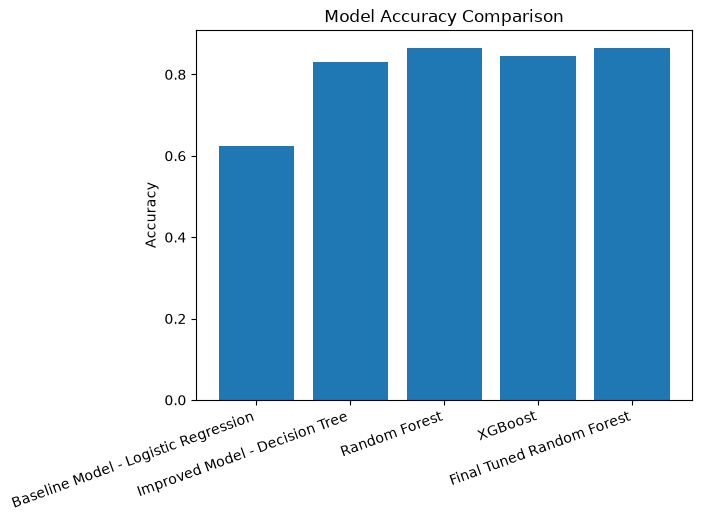

In [187]:
plt.figure()
plt.bar(comparison_df['model'], comparison_df['accuracy'])
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
plt.xticks(rotation=20, ha='right')
plt.show()

Hyperparameter tuning identified an optimal Random Forest configuration with a cross-validation accuracy of 91.5%. Although the independent test accuracy remained 86.5%, the tuned model was selected because it represents the best-performing and systematically validated configuration discovered during the tuning process.

## 10. Explainability — Feature Importance

In [188]:
feature_names = final_tuned_rf_model.named_steps['preprocessor'].get_feature_names_out()
importances = final_tuned_rf_model.named_steps['model'].feature_importances_

importance_df = pd.DataFrame({'feature': feature_names, 'importance': importances}).sort_values('importance', ascending=False)
importance_df.head(20)

,feature,importance
67,numeric__historical_defect_count,0.161271
60,numeric__branch_instruction_count,0.122983
68,numeric__change_count_last_12_months,0.114583
65,numeric__macro_call_count,0.110810
70,numeric__unsupported_instruction_count,0.083603
69,numeric__comment_ratio,0.065515
64,numeric__database_access_count,0.063265
61,numeric__called_module_count,0.055294
63,numeric__file_io_count,0.040087
66,numeric__packed_decimal_instruction_count,0.036670


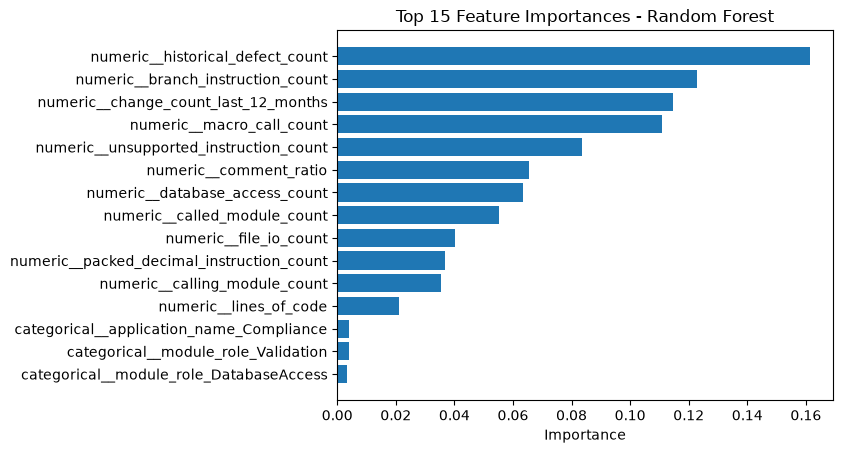

In [189]:
top_features = importance_df.head(15)

plt.figure()
plt.barh(top_features['feature'], top_features['importance'])
plt.title('Top 15 Feature Importances - Random Forest')
plt.xlabel('Importance')
plt.gca().invert_yaxis()
plt.show()

### ## Explainability — SHAP Analysis

In [199]:
#SHAP Values for Model Interpretability
# SHAP setup for model interpretability
import shap
import numpy as np
import pandas as pd

# Transform test data using the trained preprocessor
X_test_transformed = final_tuned_rf_model.named_steps["preprocessor"].transform(X_test)

# Convert sparse matrix to dense array if needed
if hasattr(X_test_transformed, "toarray"):
    X_test_transformed = X_test_transformed.toarray()

# SHAP needs numeric values
X_test_transformed = X_test_transformed.astype(float)

# Extract trained Random Forest model
rf = final_tuned_rf_model.named_steps["model"]

# Get transformed feature names
feature_names = final_tuned_rf_model.named_steps["preprocessor"].get_feature_names_out()

# Create SHAP explainer
explainer = shap.TreeExplainer(rf)

# Create SHAP explanation object for first 100 test records
shap_explanation = explainer(X_test_transformed[:100])

print("SHAP explanation generated successfully.")
print("Shape of SHAP values:", shap_explanation.values.shape)

SHAP explanation generated successfully.
Shape of SHAP values: (100, 71, 3)


In [200]:
# SHAP explanation table for one sample module

sample_index = 0

# Predict risk for selected test module
predicted_class_name = rf.predict(
    X_test_transformed[[sample_index]]
)[0]

# Find class index
class_names = list(rf.classes_)
predicted_class_index = class_names.index(predicted_class_name)

print("Selected sample index:", sample_index)
print("Predicted risk level:", predicted_class_name)

# Extract SHAP values for selected sample and predicted class
sample_shap_values = shap_explanation.values[
    sample_index, :, predicted_class_index
]

# Create explanation table
shap_df = pd.DataFrame({
    "feature": feature_names,
    "shap_value": sample_shap_values,
})

# Add impact meaning
shap_df["impact"] = np.where(
    shap_df["shap_value"] > 0,
    "Increased predicted risk",
    "Reduced predicted risk"
)

# Sort by strongest impact
shap_df["absolute_impact"] = shap_df["shap_value"].abs()

top_shap_factors = (
    shap_df
    .sort_values("absolute_impact", ascending=False)
    .head(10)
    .drop(columns=["absolute_impact"])
)

top_shap_factors


Selected sample index: 0
Predicted risk level: High


,feature,shap_value,impact
67,numeric__historical_defect_count,0.151752,Increased predicted risk
65,numeric__macro_call_count,0.101391,Increased predicted risk
60,numeric__branch_instruction_count,0.098196,Increased predicted risk
64,numeric__database_access_count,0.063634,Increased predicted risk
69,numeric__comment_ratio,0.051255,Increased predicted risk
68,numeric__change_count_last_12_months,0.048637,Increased predicted risk
66,numeric__packed_decimal_instruction_count,0.038918,Increased predicted risk
70,numeric__unsupported_instruction_count,0.027087,Increased predicted risk
14,categorical__business_process_Balance Maintenance,-0.018018,Reduced predicted risk
62,numeric__calling_module_count,0.017729,Increased predicted risk


## 11. Risk Prediction Demo

In [197]:
sample_module = pd.DataFrame([
    {
        'application_name': 'Credit Cards',
        'business_process': 'Fraud Detection',
        'module_role': 'Validation',
        'lines_of_code': 420,
        'branch_instruction_count': 95,
        'called_module_count': 8,
        'calling_module_count': 4,
        'file_io_count': 2,
        'database_access_count': 3,
        'macro_call_count': 15,
        'packed_decimal_instruction_count': 10,
        'historical_defect_count': 18,
        'change_count_last_12_months': 21,
        'comment_ratio': 0.05,
        'unsupported_instruction_count': 5,
    }
])

prediction = final_tuned_rf_model.predict(sample_module)[0]
probabilities = final_tuned_rf_model.predict_proba(sample_module)[0]
classes = final_tuned_rf_model.named_steps['model'].classes_

confidence_df = pd.DataFrame({'risk_level': classes, 'probability': probabilities}).sort_values('probability', ascending=False)

print('Predicted Risk:', prediction)
confidence_df

Predicted Risk: Medium


,risk_level,probability
2,Medium,0.561936
0,High,0.394188
1,Low,0.043876


## 12. Save Artifacts

In [198]:
MODEL_PATH = ARTIFACTS_DIR / 'risk_model.pkl'
METRICS_PATH = ARTIFACTS_DIR / 'model_metrics.json'
FEATURE_IMPORTANCE_PATH = ARTIFACTS_DIR / 'feature_importance.csv'
MODEL_COMPARISON_PATH = ARTIFACTS_DIR / 'model_comparison.csv'

joblib.dump(final_tuned_rf_model, MODEL_PATH)

metrics = {
    'final_model': 'Final Tuned Random Forest',
    'best_parameters': grid_search.best_params_,
    'best_cross_validation_accuracy': round(grid_search.best_score_, 4),
    'accuracy': round(final_tuned_rf_results['accuracy'], 4),
    'classification_report': final_tuned_rf_results['classification_report'],
    'confusion_matrix_labels': ['Low', 'Medium', 'High'],
    'confusion_matrix': final_tuned_rf_results['confusion_matrix'],
    'features_used': CATEGORICAL_COLUMNS + NUMERIC_COLUMNS,
    'dropped_columns': DROP_COLUMNS,
}

with open(METRICS_PATH, 'w', encoding='utf-8') as f:
    json.dump(metrics, f, indent=2)

importance_df.to_csv(FEATURE_IMPORTANCE_PATH, index=False)
comparison_df.to_csv(MODEL_COMPARISON_PATH, index=False)

print('Saved final model:', MODEL_PATH)
print('Saved metrics:', METRICS_PATH)
print('Saved feature importance:', FEATURE_IMPORTANCE_PATH)
print('Saved model comparison:', MODEL_COMPARISON_PATH)

Saved final model: c:\Users\dhanu\HLASM-to-Java-Translator-with-ML-Based-Behavioral-Validation\ml_risk_predictor\artifacts\risk_model.pkl
Saved metrics: c:\Users\dhanu\HLASM-to-Java-Translator-with-ML-Based-Behavioral-Validation\ml_risk_predictor\artifacts\model_metrics.json
Saved feature importance: c:\Users\dhanu\HLASM-to-Java-Translator-with-ML-Based-Behavioral-Validation\ml_risk_predictor\artifacts\feature_importance.csv
Saved model comparison: c:\Users\dhanu\HLASM-to-Java-Translator-with-ML-Based-Behavioral-Validation\ml_risk_predictor\artifacts\model_comparison.csv


## 13. Conclusions

This notebook completed the Week 1 ML flow:

- Loaded the Enterprise Banking HLASM dataset
- Reviewed risk distribution and module metrics
- Cleaned and prepared the data
- Trained a baseline model
- Trained improved models
- Selected Random Forest as the final model
- Generated feature importance for explainability
- Produced a sample risk prediction with confidence
- Saved model artifacts for dashboard and prediction use